In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys
from PIL.ImageColor import colormap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit
from pathlib import Path

project_root = next((p for p in [Path.cwd(), *Path.cwd().parents] if p.name == "discretize"), None)
if project_root is None:
    raise FileNotFoundError("Could not locate project root folder named 'discretize'.")

print("Project root path:")
print(project_root)

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from configuration.settings import *
from model.fuelcell import PEMFC_1D
from model.coefficients import *
from model.states import *
from configuration.sim_initialize import *

prj_root = project_root.as_posix() + "/"
dataset_path = project_root / "data" / "polarization"
info_data = pd.read_excel(dataset_path / "DATAFILES_LIST.xlsx")

Project root path:
c:\Users\yukwa\Dropbox\PhD folder\Codes\dual-scale model\discretize


In [2]:
delta_i = 0.3e4
delta_t_ini = 0
delta_t_load = 20
delta_t_break = 400
i_max = 1.3e5
delta_pola = (delta_t_load, delta_t_break, delta_i, delta_t_ini)
# s. It is the time of one load.
delta_t = delta_t_load + delta_t_break  
# s. The duration of this polarization current.
tf = delta_t_ini + int(i_max / delta_i + 1) * delta_t  
# Load number 
n = int(tf / delta_t) 
t0_interval = 0
tf_interval = (delta_t_ini + int(i_max / delta_i + 1) * (delta_t_load + delta_t_break))
time_interval_pola = (t0_interval, tf_interval)
tf_up = n * delta_t + delta_t_ini
def pola_profile(t):
    # Upward current density for the polarization curve
    i_fc = 0.01  # A.m-2. Initialisation of the current density.
    for i in range(n):
        t_switch = delta_t * i  # The current density value changes around this time
        i_fc += delta_i * (1.0 + np.tanh(4 * (t - delta_t_ini - delta_t - t_switch - (delta_t_load / 2))/delta_t_load)) / 2
    return i_fc

In [3]:
def make_monitored_rhs(model):
    names = model.solver_variable_names
    def rhs(t, y):
        y = np.asarray(y, dtype=float)
        bad_y = ~np.isfinite(y)
        if bad_y.any():
            idx = int(np.flatnonzero(bad_y)[0])
            raise FloatingPointError(f"State abnormal at t={t:.6g}: {names[idx]} = {y[idx]}")
        dy = np.asarray(model.dxdt(t, y), dtype=float)
        bad_dy = ~np.isfinite(dy)
        if bad_dy.any():
            idx = int(np.flatnonzero(bad_dy)[0])
            raise FloatingPointError(f"Derivative abnormal at t={t:.6g}: d({names[idx]})/dt = {dy[idx]}, state={y[idx]}")
        return dy
    return rhs


In [4]:
# Dictionary to store simulation results for each temperature
simulation_results = {}

# Locate end of upward ramp and start of downward ramp
tf_up_end = tf_interval
tf_down_start = tf_interval + 50

for idx, Tdes in enumerate([50, 60]):

    statelog = {}
    operating_inputs["Tfc"] = Tdes + 273.15 
    operating_inputs["current_density"] = pola_profile
    # Current increase
    model = PEMFC_1D(parameters, operating_inputs, initial_variable_values)
    rhs = make_monitored_rhs(model)
    sol = solve_ivp(rhs, (0, tf_interval), model.x, method='BDF', max_step=1e-1)
    model._recovery(sol)

    t_sim = model.variables["t"]
    for key in model.variables.keys():
        statelog[key] = model.variables[key]
    for key in model.elec_variables.keys():
        statelog[key] = model.elec_variables[key]

    # Read corresponding experimental data
    FSC_target = model.operating_inputs["Sc"]
    TFC_target = model.operating_inputs["Tfc"] - 273.15
    fname = str(info_data[(info_data["Group"] == 4) & (info_data["FSC"] == FSC_target) & (info_data["TFC_DegC"] == TFC_target)]["FILENAME_TESTBENCH"].values[0])
    path = Path(dataset_path) / f"{fname}.xlsx"
    expdata = pd.read_excel(path)
    t_exp = expdata["tps(s)"].values
    I_exp = expdata["I_LOAD_A"].values
    U_exp = expdata["VFC_10V"].values
    I_sim = np.array(statelog["i_fc"]) * model.parameters["Aact"]
    U_sim = np.array(statelog["Ucell"]) * n_cell

    simulation_results[Tdes] = {"t_sim": t_sim, "I_sim": I_sim, "U_sim": U_sim,
                                                     "t_exp": t_exp,  "I_exp": I_exp, "U_exp": U_exp,
                                                     "model": model, "state_log": statelog}

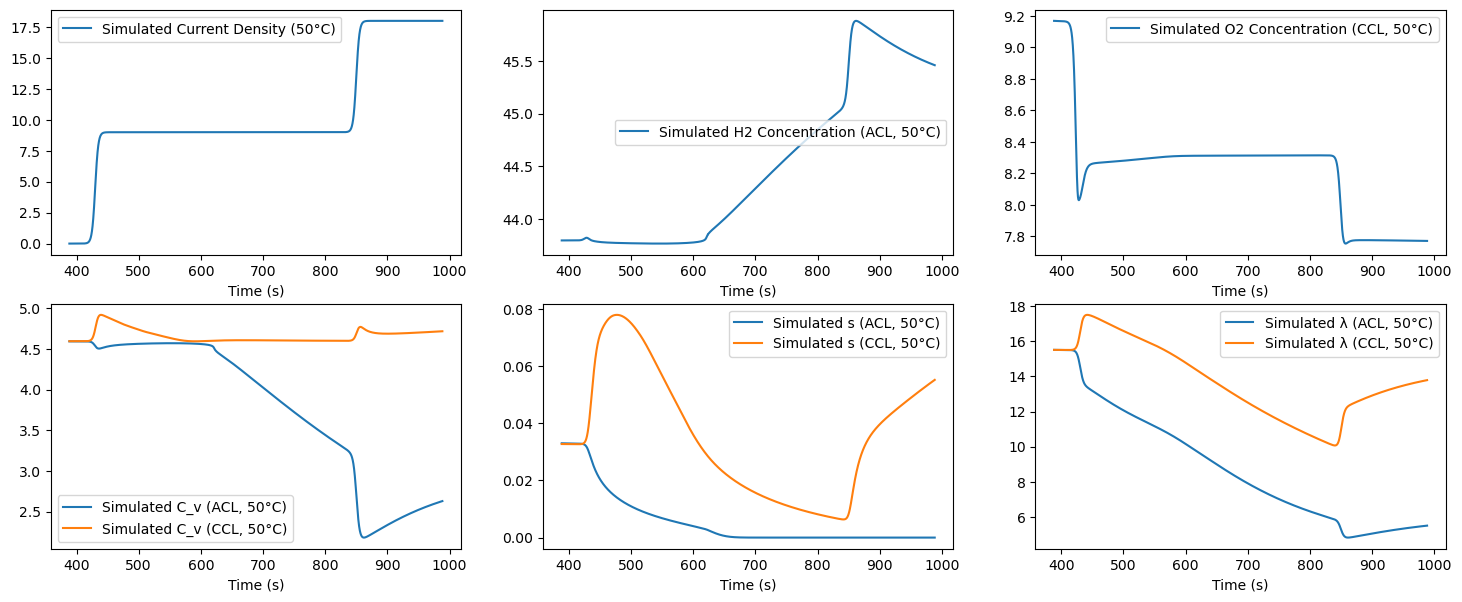

In [10]:
i_start = 4000
i_end = 10000
fig, axes = plt.subplots(2, 3, figsize=(6 * 3, 3.5 * 2))
axes[0, 0].plot(simulation_results[50]["t_sim"][i_start:i_end], simulation_results[50]["I_sim"][i_start:i_end], label="Simulated Current Density (50°C)")
axes[0, 1].plot(simulation_results[50]["t_sim"][i_start:i_end], simulation_results[50]["state_log"]["C_H2_acl"][i_start:i_end], label="Simulated H2 Concentration (ACL, 50°C)")
axes[0, 2].plot(simulation_results[50]["t_sim"][i_start:i_end], simulation_results[50]["state_log"]["C_O2_ccl"][i_start:i_end], label="Simulated O2 Concentration (CCL, 50°C)")
axes[1, 0].plot(simulation_results[50]["t_sim"][i_start:i_end], simulation_results[50]["state_log"]["C_v_acl"][i_start:i_end], label="Simulated C_v (ACL, 50°C)")
axes[1, 0].plot(simulation_results[50]["t_sim"][i_start:i_end], simulation_results[50]["state_log"]["C_v_ccl"][i_start:i_end], label="Simulated C_v (CCL, 50°C)")
axes[1, 1].plot(simulation_results[50]["t_sim"][i_start:i_end], simulation_results[50]["state_log"]["s_acl"][i_start:i_end], label="Simulated s (ACL, 50°C)")
axes[1, 1].plot(simulation_results[50]["t_sim"][i_start:i_end], simulation_results[50]["state_log"]["s_ccl"][i_start:i_end], label="Simulated s (CCL, 50°C)")
axes[1, 2].plot(simulation_results[50]["t_sim"][i_start:i_end], simulation_results[50]["state_log"]["lambda_acl"][i_start:i_end], label="Simulated λ (ACL, 50°C)")
axes[1, 2].plot(simulation_results[50]["t_sim"][i_start:i_end], simulation_results[50]["state_log"]["lambda_ccl"][i_start:i_end], label="Simulated λ (CCL, 50°C)")
for ax in axes.flatten():
    ax.legend()
    ax.set_xlabel("Time (s)")

In [6]:
# Build 1D nodes (same structure used by Cell 9)
Hgc, Hgdl, Hcl, Hmem = (model.parameters[k] for k in ("Hgc", "Hgdl", "Hcl", "Hmem"))
mk = lambda p, s: [f"{p}_{s}_{i+1}" for i in range(n_gdl)]
mem = lambda p: [f"{p}_mem_{i+1}" for i in range(n_mem)]
x0, x1, x2, x3, x4, x5, x6, x7 = 0, Hgc, Hgc + Hgdl, Hgc + Hgdl + Hcl, Hgc + Hgdl + Hcl + Hmem, Hgc + Hgdl + Hcl + Hmem + Hcl, Hgc + 2 * Hgdl + 2 * Hcl + Hmem, 2 * Hgc + 2 * Hgdl + 2 * Hcl + Hmem

nodes_vp = ["C_v_agc"] + mk("C_v", "agdl") + ["C_v_acl"] + [0] * n_mem + ["C_v_ccl"] + mk("C_v", "cgdl") + ["C_v_cgc"]
nodes_O2 = [0] + [0] * n_gdl + [0] + [f"C_O2_mem_{i+1}" for i in range(n_mem)] + ["C_O2_ccl"] + mk("C_O2", "cgdl") + ["C_O2_cgc"]
nodes_H2 = ["C_H2_agc"] + mk("C_H2", "agdl") + ["C_H2_acl"] + [f"C_H2_mem_{i+1}" for i in range(n_mem)] + [0] + [0] * n_gdl + [0]
nodes_s = [0] + mk("s", "agdl") + ["s_acl"] + [0] * n_mem + ["s_ccl"] + mk("s", "cgdl") + [0]
nodes_lambda = [0] + [0] * n_gdl + ["lambda_acl"] + mem("lambda") + ["lambda_ccl"] + [0] * n_gdl + [0]
nodes_temp = [f"Tagdl_{i+1}" for i in range(n_gdl)] + ["Tacl"] + [f"Tmem_{i+1}" for i in range(n_mem)] + ["Tccl"] + [f"Tcgdl_{i+1}" for i in range(n_gdl)]

gc_offset = min(10e-6, 0.49 * Hgc)
x_agc = x1 - gc_offset
x_cgc = x6 + gc_offset
nodes_x = np.r_[x_agc, np.linspace(x1, x2, n_gdl), (x2 + x3) / 2,
               np.linspace(x3, x4, n_mem),
               (x4 + x5) / 2, np.linspace(x5, x6, n_gdl), x_cgc]
borders = [x0, x1, x2, x3, x4, x5, x6, x7]

# Plot 1D profiles (same layout as Cell 9)
variable_groups = {
    'Water vapor': nodes_vp,
    'Oxygen': nodes_O2,
    'Hydrogen': nodes_H2,
    'Liquid saturation': nodes_s,
    'Water content': nodes_lambda,
    'Temperature': nodes_temp
}

solver_idx = {name: i for i, name in enumerate(model.solver_variable_names)}
x_um = np.asarray(nodes_x, dtype=float) * 1e6
xlim = (np.nanmin(x_um) - 5, np.nanmax(x_um) + 5)
inset_specs = {
    1: {"loc": "upper left"},
    2: {"loc": "upper right"},
    4: {"loc": "upper left"},
    5: {"loc": "lower right"}
}

x_acl_mem_ccl = np.array([x2, x5], dtype=float) * 1e6
zoom_pad = max(1.0, 0.05 * (x_acl_mem_ccl[1] - x_acl_mem_ccl[0]))
x_zoom_left, x_zoom_right = x_acl_mem_ccl[0] - zoom_pad, x_acl_mem_ccl[1] + zoom_pad

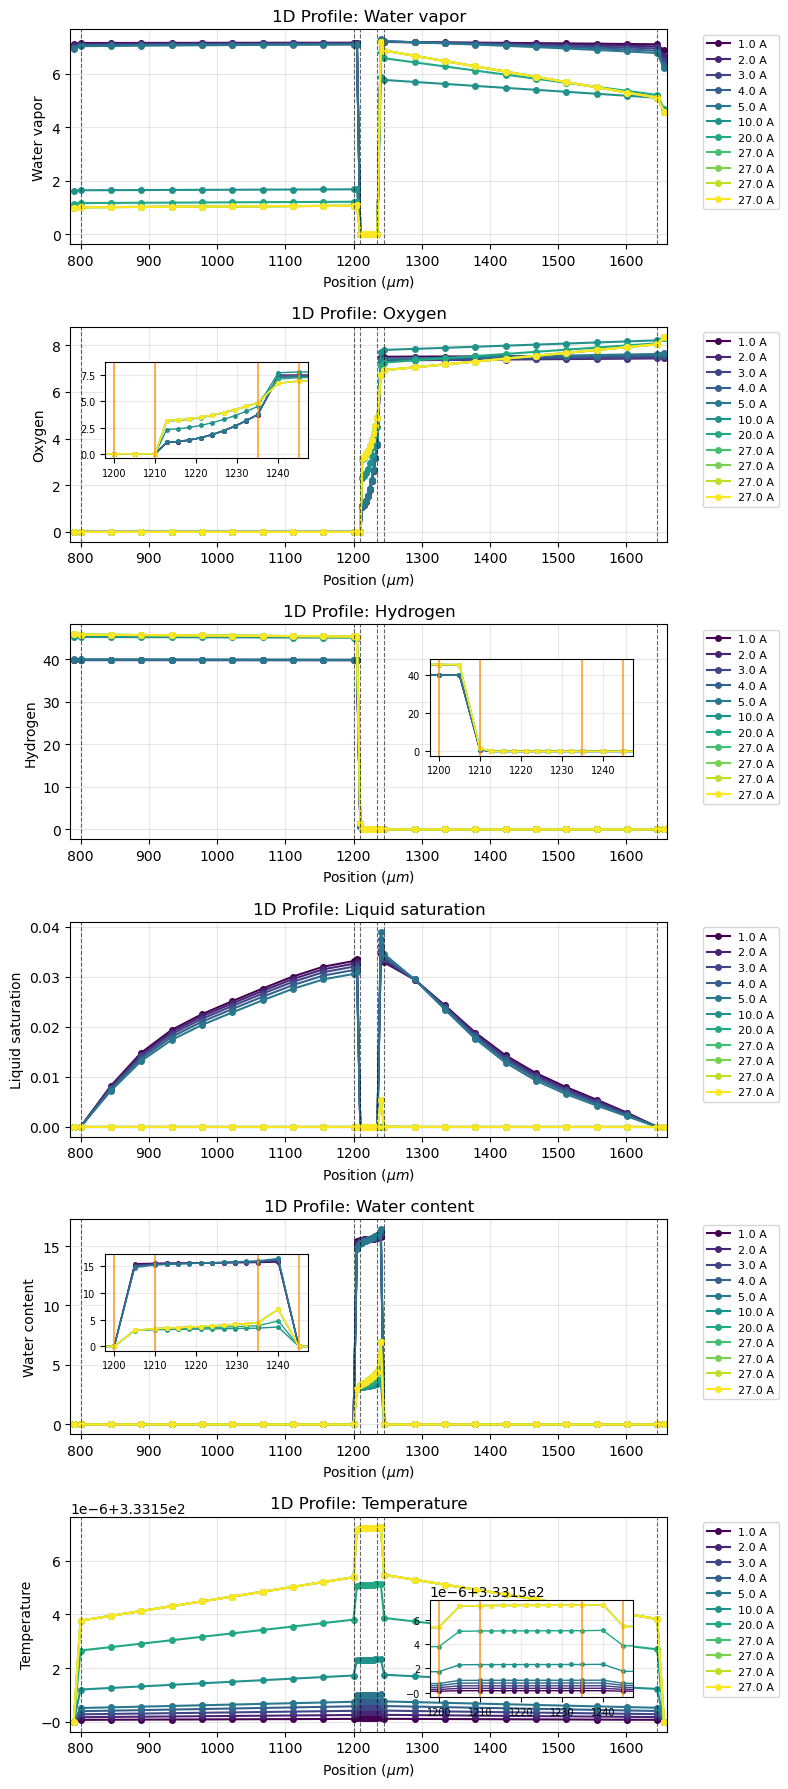

In [7]:
statelog = simulation_results[60]["state_log"]
variable_groups["Temperature"] = [333.15] + nodes_temp + [333.15]
# Find closest current points
target_currents = [1, 2, 3, 4, 5, 10, 20, 30, 40, 42, 45]
I_sim = np.array(model.elec_variables["i_fc"]) * model.parameters["Aact"]

# Find closest indices
closest_indices = []
closest_currents = []

for target in target_currents:
    idx = np.argmin(np.abs(I_sim - target))
    closest_indices.append(idx)
    closest_currents.append(I_sim[idx])
# Create subplots - one row per variable type
fig, axes = plt.subplots(len(variable_groups), 1, figsize=(8, 3 * len(variable_groups)))
if len(variable_groups) == 1:
    axes = [axes]

for ax_idx, (var_name, node_list) in enumerate(variable_groups.items()):
    ax = axes[ax_idx]
    ins = None

    if ax_idx in inset_specs:
        spec = inset_specs[ax_idx]
        ins = inset_axes(ax, width='34%', height='45%', loc=spec['loc'], borderpad=2.5)

    # Plot for each selected current point
    for i, (idx, current) in enumerate(zip(closest_indices, closest_currents)):
        values = []
        x_positions = []

        for node_idx, node_name in enumerate(node_list):
            x_positions.append(x_um[node_idx])
            if isinstance(node_name, (int, float, np.floating)) and not isinstance(node_name, bool):
                values.append(float(node_name))
            elif node_name == '0':
                values.append(0.0)
            elif node_name in statelog:
                arr = np.asarray(statelog[node_name], dtype=float)
                values.append(arr[idx] if arr.ndim > 0 and idx < arr.shape[0] else np.nan)
            elif node_name in solver_idx and hasattr(sol, 'y') and idx < sol.y.shape[1]:
                values.append(float(sol.y[solver_idx[node_name], idx]))
            else:
                values.append(np.nan)

        color = plt.cm.viridis(i / max(1, len(closest_indices) - 1))
        ax.plot(x_positions, values, 'o-', label=f'{current:.1f} A', color=color, markersize=4)
        if ins is not None:
            ins.plot(x_positions, values, 'o-', color=color, markersize=2.5, linewidth=1.0)

    # Plot region borders as vertical lines
    for border in borders:
        ax.axvline(border * 1e6, color='k', linestyle='--', linewidth=0.8, alpha=0.6)

    ax.set_xlabel('Position $(\\mu m)$')
    ax.set_ylabel(var_name)
    ax.set_title(f'1D Profile: {var_name}')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(*xlim)

    if ins is not None:
        ins.set_xlim(x_zoom_left, x_zoom_right)

        for border in borders:
            xb = border * 1e6
            if x_zoom_left <= xb <= x_zoom_right:
                ins.axvline(xb, color='darkorange', linestyle='-', linewidth=1.2, alpha=0.8)

        ins.grid(True, alpha=0.25)
        ins.tick_params(labelsize=7)

plt.tight_layout()
plt.show()


Indices: [4365, 4386, 4400, 4412, 4423, 8615, 12836, 13113, 13113, 13113, 13113]
Actual currents: ['0.990', '2.002', '3.004', '4.027', '5.013', '9.997', '20.015', '26.999', '26.999', '26.999', '26.999']


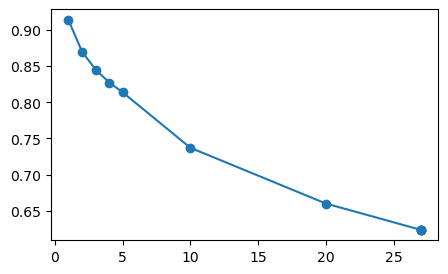

In [8]:
print(f"\nIndices: {closest_indices}")
print(f"Actual currents: {[f'{c:.3f}' for c in closest_currents]}")
plt.figure(figsize=(5, 3))
plt.plot(closest_currents, [statelog['Ucell'][idx] for idx in closest_indices], 'o-')

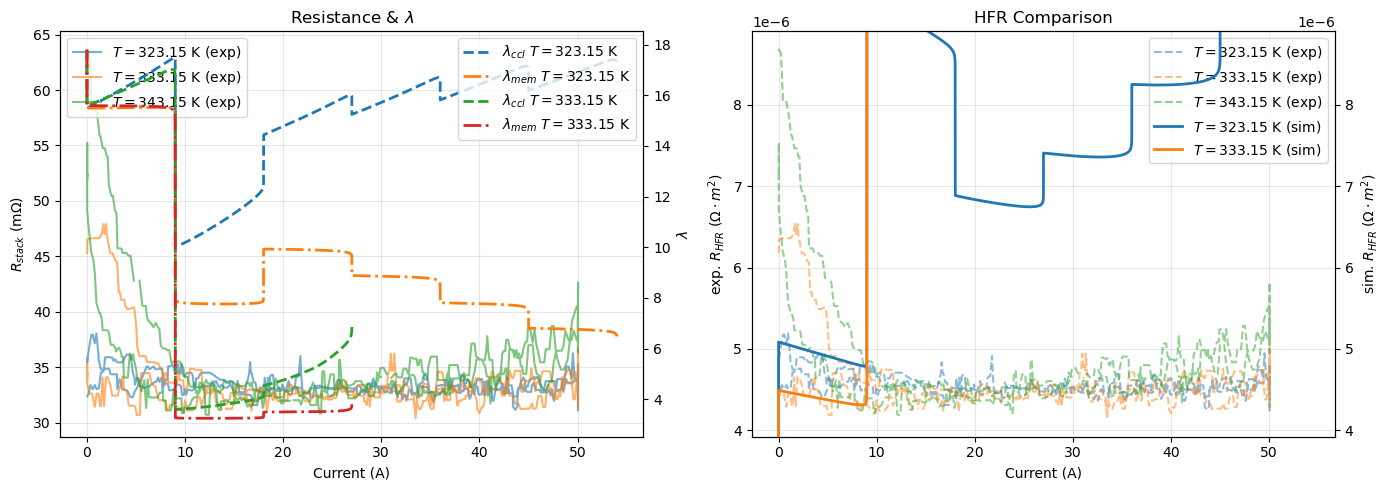

In [9]:
from scipy.signal import medfilt

def get_lambda_mem_series(state, n_mem):
    mem_keys = [f"lambda_mem_{i}" for i in range(1, n_mem + 1) if f"lambda_mem_{i}" in state]
    if mem_keys:
        arrays = [np.asarray(state[k], dtype=float) for k in mem_keys]
        arrays = [arr for arr in arrays if arr.ndim > 0 and arr.size > 0]
        if arrays:
            min_len = min(arr.shape[0] for arr in arrays)
            if min_len > 0:
                stacked = np.vstack([arr[:min_len] for arr in arrays])
                return np.nanmean(stacked, axis=0)
    fallback = np.asarray(state.get("lambda_mem", []), dtype=float)
    return fallback if fallback.ndim > 0 else np.array([])

def collect_exp_data(info_df, data_dir):
    data = []
    mask = (info_df["Group"] == 4) & (info_df["FSC"] == 2.5) & (info_df["TFC_DegC"].isin([50, 60, 70]))
    for idx, filename in info_df.loc[mask, "FILENAME_TESTBENCH"].items():
        try:
            raw = pd.read_excel(Path(data_dir) / f"{filename}.xlsx")
            current = raw["I_LOAD_A"].to_numpy(dtype=float)
            r_stack_mohm = medfilt(raw["R_mOhm"].to_numpy(dtype=float), kernel_size=5)
            label = f"$T={info_df.loc[idx, 'TFC_DegC'] + 273.15}$ K"
            data.append((current, r_stack_mohm, label))
        except Exception:
            continue
    return data

exp_data = collect_exp_data(info_data, dataset_path)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1_twin = ax1.twinx()
ax2_twin = ax2.twinx()

# Left panel: experimental R_stack + simulated lambda
for current, r_stack_mohm, label in exp_data:
    ax1.plot(current, r_stack_mohm, linestyle='-', alpha=0.6, linewidth=1.5, label=f'{label} (exp)')

for Tdes in sorted(simulation_results.keys()):
    result = simulation_results[Tdes]
    state = result["state_log"]
    params = result["model"].parameters
    i_stack = np.asarray(result["I_sim"], dtype=float)
    lambda_ccl = np.asarray(state.get("lambda_ccl", []), dtype=float)
    lambda_mem = get_lambda_mem_series(state, params["n_mem"])
    n_pts = min(i_stack.size, lambda_ccl.size, lambda_mem.size)
    if n_pts > 0:
        t_label = f"$T={Tdes + 273.15}$ K"
        ax1_twin.plot(i_stack[:n_pts], lambda_ccl[:n_pts], linewidth=2, linestyle='--', label=f'$\\lambda_{{ccl}}$ {t_label}')
        ax1_twin.plot(i_stack[:n_pts], lambda_mem[:n_pts], linewidth=2, linestyle='-.', label=f'$\\lambda_{{mem}}$ {t_label}')

ax1.set_xlabel('Current (A)')
ax1.set_ylabel(r'$R_{stack}$ (m$\Omega$)')
ax1.set_title('Resistance & $\\lambda$')
ax1.grid(True, alpha=0.3)
if ax1.get_legend_handles_labels()[0]:
    ax1.legend(loc='upper left')
ax1_twin.set_ylabel('$\\lambda$')
if ax1_twin.get_legend_handles_labels()[0]:
    ax1_twin.legend(loc='upper right')

# Right panel: experimental HFR + simulated Rp from statelog
for current, r_stack_mohm, label in exp_data:
    hfr_exp = r_stack_mohm * 1e-3 * 30e-4 / 22
    ax2.plot(current, hfr_exp, linestyle='--', alpha=0.5, label=f'{label} (exp)')

for Tdes in sorted(simulation_results.keys()):
    result = simulation_results[Tdes]
    state = result["state_log"]
    i_stack = np.asarray(result["I_sim"], dtype=float)
    rp_sim = np.asarray(state.get("Rp", []), dtype=float)
    n_pts = min(i_stack.size, rp_sim.size)
    if n_pts > 0:
        ax2_twin.plot(i_stack[:n_pts], rp_sim[:n_pts], linewidth=2, label=f'$T={Tdes + 273.15}$ K (sim)')

ax2.set_xlabel('Current (A)')
ax2.set_ylabel(r'exp. $R_{HFR}$ ($\Omega \cdot m^2$)')
ax2.set_title('HFR Comparison')
ax2_twin.set_ylim(ax2.get_ylim())
ax2.grid(True, alpha=0.3)
ax2_twin.set_ylabel(r'sim. $R_{HFR}$ ($\Omega \cdot m^2$)')

lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
if lines1 or lines2:
    ax2.legend(lines1 + lines2, labels1 + labels2, loc='best')

plt.tight_layout()
plt.show()